In [1]:
import cu_rsc as cr
cr.setup_tables()
import numpy as np
import cupy as cp
import cupyx
import matplotlib.pyplot as plt
from cycler import cycler
plt.style.use("aps.mplstyle")
import matplotlib as mpl
mpl.rcParams['axes.prop_cycle'] = cycler(
    'color',
    ['#1b9e77', '#d95f02', '#7570b3', '#e7298a',
     '#66a61e', '#e6ab02', '#a6761d', '#666666']
)
M_dev = cr.load_m_table_device()        # upload to GPU
res   = cr.resources_from_config(M_dev)

### Matrix element

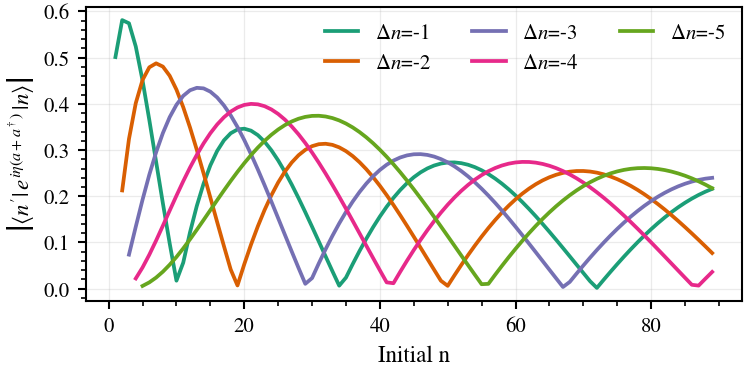

In [22]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

n_range = 90
delta_ns = np.array([-1, -2, -3, -4, -5], dtype=int)

plt.figure(figsize=(5, 2.5))

for delta_n in delta_ns:
    # indices must be ints
    n_init = cp.arange(-delta_n, n_range, dtype=cp.int32)

    # vectorized gather on GPU
    vals = res.M[n_init, n_init + delta_n, 60]   # CuPy array

    # convert once for matplotlib
    x = cp.asnumpy(n_init)
    y = cp.asnumpy(vals)

    plt.plot(x, np.abs(y),label=f"$\\Delta n$={delta_n}")

plt.legend(frameon=False, ncol=3)
plt.xlabel("Initial n")
plt.ylabel(r"$\left|\langle n'|\,e^{i\eta(a+a^\dagger)}\,|n\rangle\right|$")
plt.tick_params(axis='both', which='major')
plt.savefig("RSC_sim_cool_matrix.pdf", bbox_inches="tight")

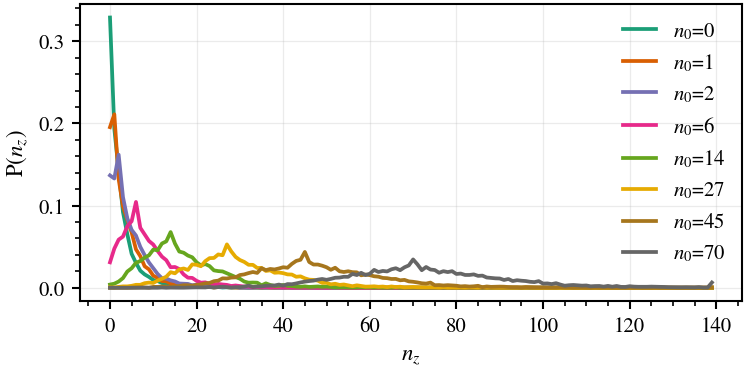

In [21]:
from cu_rsc.RSC_functions import optical_pumping
n_inits = np.array([0, 1, 2, 6, 14, 27, 45, 70], dtype=np.int32)
n_range = 140
n_vals = np.arange(n_range)

Nmc = 10000  # Monte Carlo samples per initial state

plt.figure(figsize=(5, 2.5))

for n_init in n_inits:
    # IMPORTANT: molecules must be int32 with shape (N,6)
    mol = cp.zeros((Nmc, 8), dtype=cp.int32)
    mol[:, 2] = int(n_init)   # nz
    mol[:, 3] = -1            # state (so OP is active)
    mol[:, 4] = 0             # spin good
    mol[:, 5] = 0             # not lost

    # One optical pumping cycle
    optical_pumping(mol, res, K_max=12)

    # Keep only survivors if you want a conditional distribution
    surv = (mol[:, 5] == 0)
    nz = mol[surv, 2]

    # Histogram on GPU then move to CPU for plotting
    counts = cp.bincount(cp.clip(nz, 0, n_range - 1), minlength=n_range).astype(cp.float64)
    denom = int(surv.sum().get())
    prob = (counts / max(denom, 1)).get()

    plt.plot(n_vals, prob, label="$n_0$" + f"={n_init}")

plt.xlabel("$n_z$")
plt.ylabel("P($n_z$)")
plt.tick_params(axis='both', which='major')
plt.legend(frameon=False)
plt.savefig("RSC_sim_op_prob.pdf", bbox_inches="tight")

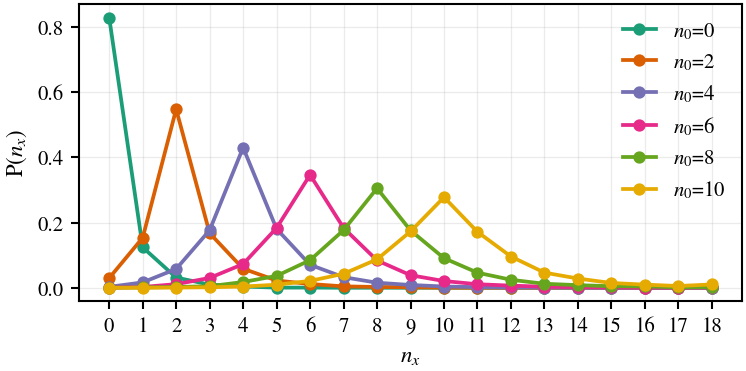

In [7]:
from cu_rsc.RSC_functions import optical_pumping
n_inits = np.array([0, 2, 4, 6, 8, 10], dtype=np.int32)
n_range = 19
n_vals = np.arange(n_range)

Nmc = 10000  # Monte Carlo samples per initial state

plt.figure(figsize=(5, 2.5))

for n_init in n_inits:
    # IMPORTANT: molecules must be int32 with shape (N,6)
    mol = cp.zeros((Nmc, 8), dtype=cp.int32)
    mol[:, 0] = int(n_init)   # nz
    mol[:, 3] = -1            # state (so OP is active)
    mol[:, 4] = 0             # spin good
    mol[:, 5] = 0             # not lost

    # One optical pumping cycle
    optical_pumping(mol, res, K_max=12)

    # Keep only survivors if you want a conditional distribution
    surv = (mol[:, 5] == 0)
    nx = mol[surv, 0]

    # Histogram on GPU then move to CPU for plotting
    counts = cp.bincount(cp.clip(nx, 0, n_range - 1), minlength=n_range).astype(cp.float64)
    denom = int(surv.sum().get())
    prob = (counts / max(denom, 1)).get()

    plt.plot(n_vals, prob, 'o-', label="$n_0$" + f"={n_init}")

plt.xlabel("$n_x$")
plt.ylabel("P($n_x$)")
plt.minorticks_off()
plt.tick_params(axis='both', which='major')
plt.legend(frameon=False)
from matplotlib.ticker import MultipleLocator
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))
plt.savefig("RSC_sim_op_prob_x.pdf", bbox_inches="tight")

### Initial distribution

In [18]:
temp = [25e-6, 25e-6, 25e-6]
mol_ref = cr.build_thermal_molecules(100000, temp)
dist_ref = cr.get_n_distribution_gpu(mol_ref, max_bins=10, plot=(False, False, False))

In [19]:
data_x = dist_ref[0]
data_z = dist_ref[2]

# Sort data
n_x = np.array(sorted(data_x.keys()))
dis_x = np.array([data_x[k] for k in n_x], dtype=float)

n_z = np.array(sorted(data_z.keys()))
dis_z = np.array([data_z[k] for k in n_z], dtype=float)


# Normalize
dis_x /= dis_x.sum()
dis_z   /= dis_z.sum()


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Interpolation
f_x = interp1d(n_x, dis_x, kind='linear', fill_value="extrapolate")
f_z   = interp1d(n_z,   dis_z,   kind='linear', fill_value="extrapolate")

# Common dense n-axis for smooth plotting

n_min = min(n_x.min(), n_z.min())
n_max = 200
n_dense = np.linspace(n_min, n_max, 500)
dis_x_dense = f_x(n_dense)
dis_z_dense = f_z(n_dense)
# Avoid small negative values from extrapolation/interpolation
dis_x_dense = np.clip(dis_x_dense, 0, None)
dis_z_dense = np.clip(dis_z_dense, 0, None)

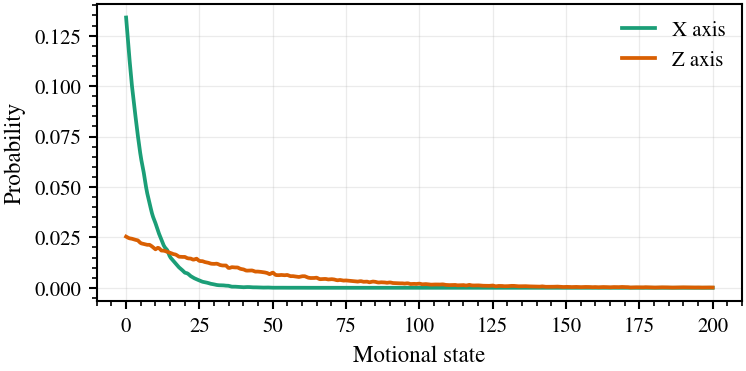

In [39]:
# --- X distribution ---
plt.figure(figsize=(5, 2.5))
plt.plot(n_dense, dis_x_dense, label="X axis", color='C0')
plt.plot(n_dense, dis_z_dense, label="Z axis", color='C1')
plt.xlabel("Motional state")
plt.ylabel("Probability")
plt.legend(frameon=False)
plt.savefig("RSC_initial_distribution.pdf", bbox_inches="tight")


Text(0, 0.5, 'Probability')

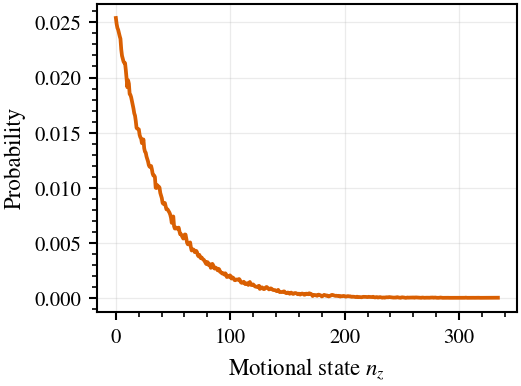

In [22]:
# --- Z distribution ---
plt.figure()
plt.plot(n_z_dense, dis_z_dense, label="Z thermal distribution", color='C1')
plt.xlabel("Motional state $n_x$")
plt.ylabel("Probability")